# Analise dos dados da Telemetria
Ainda é um rascunho, mas a ideia é que ja funcione

## Instalar bibliotecas

In [476]:
!pip install pandas numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable


## Fazer o import das bibliotecas e funções necessarias

In [494]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

#upload do arquivo a ser analisado
dados_coletados_trial01 = '/home/watsonvilar/teste_telemetria_prd/Telemetria/coletas/dados de teste UFRN/trial_01/trial01-pt1 arquivo mudado e completo.csv'
dados_coletados_trial02 = '/home/watsonvilar/teste_telemetria_prd/Telemetria/coletas/dados de teste UFRN/trial_02/trial02.csv'
dados_coletados_trial03 = '/home/watsonvilar/teste_telemetria_prd/Telemetria/coletas/dados de teste UFRN/trial_03/trial03.csv'
dados_coletados_trial04 = '/home/watsonvilar/teste_telemetria_prd/Telemetria/coletas/dados de teste UFRN/trial_04/trial04.csv'

## Tratamento dos dados, limpezas e tudo que for necessario fazer

mude para ',' se o CSV usar vírgula
tabela_dados_trial01 = pd.read_csv(dados_coletados_trial01, sep=';') #o nome 'df' é uma abreviação de 'DataFrame', encare isso como uma boa pratica, mas poderia ser "dado_tratado" ou qualquer outro nome


o nome 'df' é uma abreviação de 'DataFrame', encare isso como uma boa pratica, mas poderia ser "dado_tratado" ou qualquer outro nome

In [495]:
tabela_dados_trial01 = pd.read_csv(dados_coletados_trial01, sep=';')
tabela_dados_trial02 = pd.read_csv(dados_coletados_trial02, sep=';') 
tabela_dados_trial03 = pd.read_csv(dados_coletados_trial03, sep=';') 
tabela_dados_trial04 = pd.read_csv(dados_coletados_trial04, sep=';')

transformar as colunas relevantes em vetores NumPy
Substitua 'rssi', 'packet_id' e 'pacotes_perdidos' pelos nomes exatos das colunas do seu CSV
voce pode usar esse formado para facilitar as analises, basta pegar o 'df' e dizer qual a coluna vc quer, se o arquivo tiver um cabeçalho basta pegar o nome da coluna e passar pra vetor numpy como pode ser vito


In [496]:
rssi_vetor_trial_01 = tabela_dados_trial01['rssi'].to_numpy()
rssi_vetor_trial_02 = tabela_dados_trial02['rssi'].to_numpy()
rssi_vetor_trial_03 = tabela_dados_trial03['rssi'].to_numpy()
rssi_vetor_trial_04 = tabela_dados_trial04['rssi'].to_numpy()

In [497]:
snr_vetor_trial_01 = tabela_dados_trial01.iloc[:, 5].to_numpy()
snr_vetor_trial_02 = tabela_dados_trial02.iloc[:, 5].to_numpy()
snr_vetor_trial_03 = tabela_dados_trial03.iloc[:, 5].to_numpy()
snr_vetor_trial_04 = tabela_dados_trial04.iloc[:, 5].to_numpy()


In [498]:
prr_vetor_trial_01 = tabela_dados_trial01.iloc[:, 4].to_numpy()
prr_vetor_trial_02 = tabela_dados_trial02.iloc[:, 4].to_numpy()
prr_vetor_trial_03 = tabela_dados_trial03.iloc[:, 4].to_numpy()
prr_vetor_trial_04 = tabela_dados_trial04.iloc[:, 4].to_numpy()

## Calculos e demais coisas do tipo

media rssi

In [499]:
rssi_medio_trial01 = np.mean(rssi_vetor_trial_01)
rssi_medio_trial02 = np.mean(rssi_vetor_trial_02)
rssi_medio_trial03 = np.mean(rssi_vetor_trial_03)
rssi_medio_trial04 = np.mean(rssi_vetor_trial_04)

In [500]:
'''
media_prr_trial_01 = np.mean(prr_vetor_trial_01)
media_prr_trial_02 = np.mean(prr_vetor_trial_02)
media_prr_trial_03 = np.mean(prr_vetor_trial_03)
media_prr_trial_04 = np.mean(prr_vetor_trial_04)
'''

prr_vetor_trial_01 = tabela_dados_trial01['prr'].iloc[-1]
prr_vetor_trial_02 = tabela_dados_trial02['prr'].iloc[-1]
prr_vetor_trial_03 = tabela_dados_trial03['prr'].iloc[-1]
prr_vetor_trial_04 = tabela_dados_trial04['prr'].iloc[-1]

In [501]:
media_snr_trial_01 = np.mean(snr_vetor_trial_01)
media_snr_trial_02 = np.mean(snr_vetor_trial_02)
media_snr_trial_03 = np.mean(snr_vetor_trial_03)
media_snr_trial_04 = np.mean(snr_vetor_trial_04)

contagem de pacotes recebidos

pegamos o último valor registrado na última linha do arquivo!

In [502]:
pacotes_recebidos_trial01 = tabela_dados_trial01['pacotes_recebidos'].iloc[-1]
pacotes_recebidos_trial02 = tabela_dados_trial02['pacotes_recebidos'].iloc[-1]
pacotes_recebidos_trial03 = tabela_dados_trial03['pacotes_recebidos'].iloc[-1]
pacotes_recebidos_trial04 = tabela_dados_trial04['pacotes_recebidos'].iloc[-1]

In [503]:
pacotes_perdidos_total_trial01 = tabela_dados_trial01['pacotes_perdidos'].iloc[-1]
pacotes_perdidos_total_trial02 = tabela_dados_trial02['pacotes_perdidos'].iloc[-1]
pacotes_perdidos_total_trial03 = tabela_dados_trial03['pacotes_perdidos'].iloc[-1]
pacotes_perdidos_total_trial04 = tabela_dados_trial04['pacotes_perdidos'].iloc[-1]

In [504]:
total_esperadotrial_01 = pacotes_recebidos_trial01 + pacotes_perdidos_total_trial01
total_esperadotrial_02 = pacotes_recebidos_trial02 + pacotes_perdidos_total_trial02
total_esperadotrial_03 = pacotes_recebidos_trial03 + pacotes_perdidos_total_trial03
total_esperadotrial_04 = pacotes_recebidos_trial04 + pacotes_perdidos_total_trial04

Taxa de perda em porcentagem

In [505]:

taxa_perda_trial01 = (pacotes_perdidos_total_trial01 / total_esperadotrial_01) * 100
taxa_perda_trial02 = (pacotes_perdidos_total_trial02 / total_esperadotrial_02) * 100
taxa_perda_trial03 = (pacotes_perdidos_total_trial03 / total_esperadotrial_03) * 100
taxa_perda_trial04 = (pacotes_perdidos_total_trial04 / total_esperadotrial_04) * 100


## Plotagem dos dados

In [506]:
#print(f"--- Resultados para trail 02---")
#print(f"RSSI Médio: {rssi_medio_trial01:.2f} dBm")
#print(f"Pacotes Recebidos: {pacotes_recebidos_trial01}")
#print(f"Pacotes Perdidos: {pacotes_perdidos_total_trial01}")
#print(f"Taxa de Perda: {taxa_perda_trial_01:.2f}%")

### Tabela dos dados

esse é a celula verdadeira


In [514]:
plot_df = pd.DataFrame({
    'Trial': ['Trial 01','Trial 02','Trial 03', 'Trial 04' ],
    'RSSI Médio (dBm)': [
        round(rssi_medio_trial01, 2),
        round(rssi_medio_trial02, 2),
        round(rssi_medio_trial03, 2),
        round(rssi_medio_trial04, 2)
        ],
    'Pacotes Recebidos': [
        pacotes_recebidos_trial01,
        pacotes_recebidos_trial02,
        pacotes_recebidos_trial03,
        pacotes_recebidos_trial04
        ],
    'Pacotes Perdidos Totais': [
        pacotes_perdidos_total_trial01,
        pacotes_perdidos_total_trial02,
        pacotes_perdidos_total_trial03,
        pacotes_perdidos_total_trial04,
        ],
    'Taxa de Perda (%)': [
        round(taxa_perda_trial01, 2),
        round(taxa_perda_trial02, 2),
        round(taxa_perda_trial03, 2),
        round(taxa_perda_trial04, 2),
        ],
    'SNR médio': [
        round(media_snr_trial_01, 2),
        round(media_snr_trial_02, 2),
        round(media_snr_trial_03, 2),
        round(media_snr_trial_04, 2),
    ],'PRR médio': [
        round(prr_vetor_trial_01, 2),
        round(prr_vetor_trial_02, 2),
        round(prr_vetor_trial_03, 2),
        round(prr_vetor_trial_04, 2),
    ]
})

esse codigo é apenas um rascunho


In [515]:
display(plot_df)

,Trial,RSSI Médio (dBm),Pacotes Recebidos,Pacotes Perdidos Totais,Taxa de Perda (%),SNR médio,PRR médio
0,Trial 01,-66.60,239,132,35.58,6.35,64.42
1,Trial 02,-69.36,236,66,21.85,7.04,78.15
2,Trial 03,-70.62,212,66,23.74,7.67,76.26
3,Trial 04,-75.53,112,11,8.94,3.86,91.06


## limpar dados SNR

In [513]:
print(prr_vetor_trial_01.dtype)
np.set_printoptions(threshold=np.inf)
print(prr_vetor_trial_01)

float64
64.42


# TESTE DE PLOTS


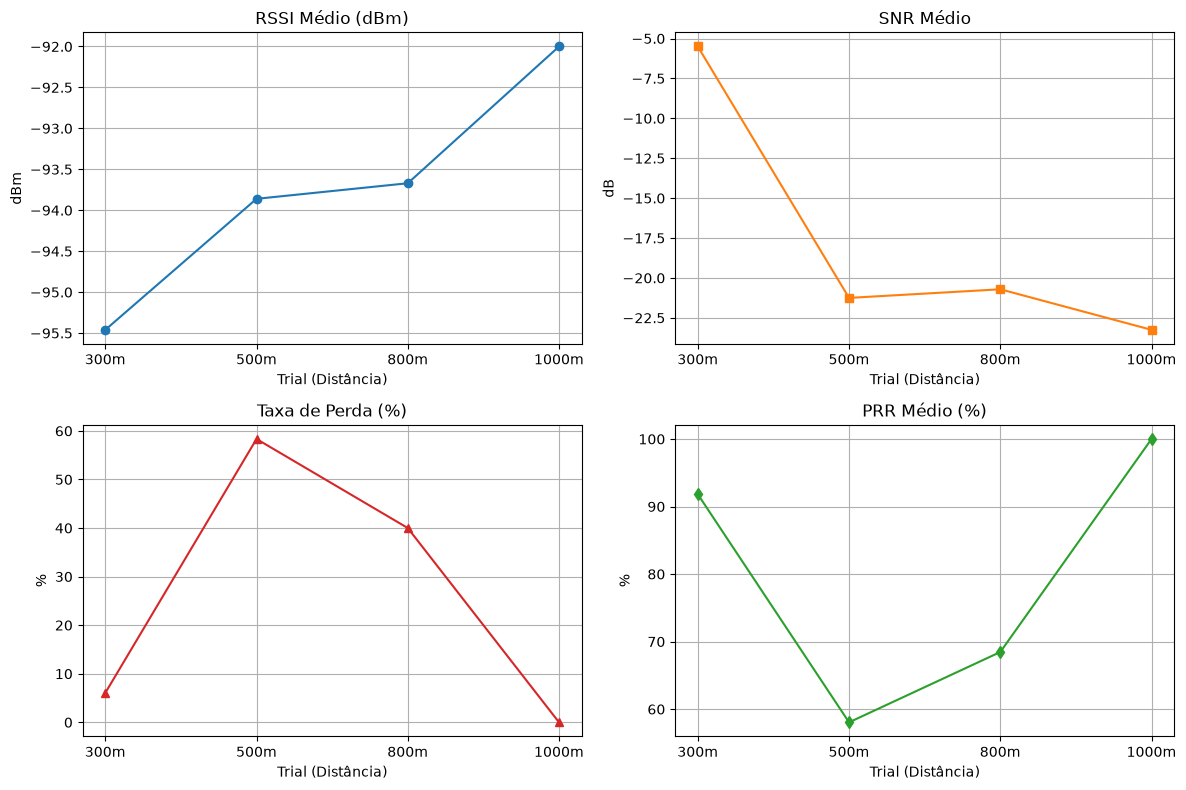

In [510]:
import matplotlib.pyplot as plt

# Dados extraídos da tabela de telemetria
trials = ['300m', '500m', '800m', '1000m']
rssi = [-95.46, -93.86, -93.67, -92.00]
snr = [-5.50, -21.25, -20.71, -23.25]
taxa_perda = [6.06, 58.33, 40.00, 0.00]
prr = [91.82, 58.05, 68.46, 100.00]

# Criando uma figura com 4 subplots (2x2)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# 1. RSSI Médio
axs[0, 0].plot(trials, rssi, marker='o', color='tab:blue', linestyle='-')
axs[0, 0].set_title('RSSI Médio (dBm)')
axs[0, 0].set_ylabel('dBm')
axs[0, 0].grid(True)

# 2. SNR Médio
axs[0, 1].plot(trials, snr, marker='s', color='tab:orange', linestyle='-')
axs[0, 1].set_title('SNR Médio')
axs[0, 1].set_ylabel('dB')
axs[0, 1].grid(True)

# 3. Taxa de Perda (%)
axs[1, 0].plot(trials, taxa_perda, marker='^', color='tab:red', linestyle='-')
axs[1, 0].set_title('Taxa de Perda (%)')
axs[1, 0].set_ylabel('%')
axs[1, 0].grid(True)

# 4. PRR Médio (%)
axs[1, 1].plot(trials, prr, marker='d', color='tab:green', linestyle='-')
axs[1, 1].set_title('PRR Médio (%)')
axs[1, 1].set_ylabel('%')
axs[1, 1].grid(True)

for ax in axs.flat:
    ax.set_xlabel('Trial (Distância)')

plt.tight_layout()
plt.show()